In [1]:
import os
import re
import glob
import pandas as pd
from IPython.display import display, Markdown
from collections import OrderedDict
import pylhe
from scipy.interpolate import griddata
from scipy.interpolate import interp1d
import pyslha
import xml.etree.ElementTree as ET
import pyslha
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

defaultPars = {'figure.figsize': (5, 4), 'lines.markersize' : 4, 'axes.titlesize' : 13, 'font.size' : 13,
               'axes.labelsize' : 16, 'xtick.labelsize' : 13, 'ytick.labelsize' : 13, 'legend.fontsize' : 10,
               "text.usetex": True, "font.family": "sans-serif", "font.sans-serif": ["Helvetica"],
               'font.family':'Times New Roman', 'font.serif':'Times New Roman', "savefig.dpi" : 300,
               'contour.linewidth' : 2.0, 'lines.linewidth' : 2.0, 'axes.grid' : True,
               'grid.linewidth' : 0.5, 'grid.color' : 'lightgray', 'axes.axisbelow' : True
               }
plt.rcParams.update(defaultPars) #Figure resolution
pd.set_option('display.max_rows', 200)

cm = plt.colormaps['RdYlBu']


In [2]:
pd.read_pickle('../ma5Results_axial_eff-correct.pcl')

,Signal Region,Sigma_95_exp (pb),Sigma_95_obs (pb),Sigma_theoretical (pb),SAF File,mMed (GeV),mchi (GeV),Efficiency,Efficiency_Err
0,IM0,8.534284,8.538081,0.000260,dma_1000_10,10.0,1000.0,0.096790,1.081335e-04
1,IM1,4.409492,4.414570,0.000260,dma_1000_10,10.0,1000.0,0.074766,7.341165e-05
2,IM2,3.336647,3.345726,0.000260,dma_1000_10,10.0,1000.0,0.056661,4.843259e-05
3,IM3,2.449853,2.464980,0.000260,dma_1000_10,10.0,1000.0,0.043186,3.222705e-05
4,IM4,2.141699,2.165333,0.000260,dma_1000_10,10.0,1000.0,0.032109,2.066077e-05
...,...,...,...,...,...,...,...,...,...
2049,EM8,1.148875,1.224121,0.133546,dma_500_995,995.0,500.0,0.000786,8.176605e-08
2050,EM9,1.150160,1.036460,0.133546,dma_500_995,995.0,500.0,0.000414,3.122072e-08
2051,EM10,2.043404,3.589709,0.133546,dma_500_995,995.0,500.0,0.000193,9.952975e-09
2052,EM11,2.679273,2.945245,0.133546,dma_500_995,995.0,500.0,0.000083,2.792465e-09


In [3]:
pd.read_pickle('../ma5Results_axial_add_eff-correct.pcl')

,Signal Region,Sigma_95_exp (pb),Sigma_95_obs (pb),Sigma_theoretical (pb),SAF File,mMed (GeV),mchi (GeV),Efficiency,Efficiency_Err
0,IM0,41.562392,41.576814,8.470793,dma_100_10,10.0,1000.0,0.018590,9.747453e-06
1,IM1,26.835339,26.859584,8.470793,dma_100_10,10.0,1000.0,0.011417,4.691525e-06
2,IM2,25.132638,25.183693,8.470793,dma_100_10,10.0,1000.0,0.006729,2.122781e-06
3,IM3,21.957866,22.056093,8.470793,dma_100_10,10.0,1000.0,0.004156,1.030262e-06
4,IM4,22.766144,22.943636,8.470793,dma_100_10,10.0,1000.0,0.002485,4.762687e-07
...,...,...,...,...,...,...,...,...,...
1711,EM8,0.789179,0.842512,0.009061,dma_600_750,750.0,1.0,0.001213,1.559342e-07
1712,EM9,0.578438,0.521256,0.009061,dma_600_750,750.0,1.0,0.000818,8.631441e-08
1713,EM10,1.118858,2.396994,0.009061,dma_600_750,750.0,1.0,0.000395,2.900370e-08
1714,EM11,0.808475,0.889602,0.009061,dma_600_750,750.0,1.0,0.000286,1.787250e-08


In [4]:
pd.read_pickle('../ma5Results_vector_all_effs-correct.pcl')

,Signal Region,Sigma_95_exp (pb),Sigma_95_obs (pb),Sigma_theoretical (pb),SAF File,mMed (GeV),mchi (GeV),Efficiency,Efficiency_Err
0,IM0,8.669311,8.673169,0.001163,dmv_1000_10,10.0,1000.0,0.094259,1.028053e-04
1,IM1,4.378603,4.383645,0.001163,dmv_1000_10,10.0,1000.0,0.073903,7.137127e-05
2,IM2,3.262033,3.270897,0.001163,dmv_1000_10,10.0,1000.0,0.056563,4.778919e-05
3,IM3,2.419868,2.434793,0.001163,dmv_1000_10,10.0,1000.0,0.042365,3.097767e-05
4,IM4,2.009535,2.031696,0.001163,dmv_1000_10,10.0,1000.0,0.032610,2.091994e-05
...,...,...,...,...,...,...,...,...,...
3401,EM8,1.077207,1.147759,0.037832,dmv_600_750,750.0,600.0,0.000848,9.064607e-08
3402,EM9,0.843373,0.760001,0.037832,dmv_600_750,750.0,600.0,0.000539,4.585938e-08
3403,EM10,1.082148,2.104174,0.037832,dmv_600_750,750.0,600.0,0.000364,2.543220e-08
3404,EM11,1.262974,1.388347,0.037832,dmv_600_750,750.0,600.0,0.000188,9.495770e-09


In [5]:
2054/26

79.0

In [6]:
df_a1 = pd.read_pickle('../ma5Results_axial_eff-correct.pcl')
df_a2 = pd.read_pickle('../ma5Results_axial_add_effs-correct.pcl')
dfs_a = [df_a1, df_a2]

df_a = pd.concat(dfs_a, ignore_index=True)
df_v = pd.read_pickle('../ma5Results_vector_all_effs-correct.pcl')

In [7]:
# get datapoints in common
mCols = ['mMed (GeV)', 'mchi (GeV)']
keys = list(df_v[mCols].columns.values)
i1 = df_v.set_index(keys).index
i2 = df_a.set_index(keys).index
dataVec = df_v[i1.isin(i2)]
dataAx = df_a[i2.isin(i1)]
print(len(dataAx), len(dataVec))

3406 3406


In [8]:
# choose only EM
srs = [c for c in dataAx['Signal Region'] if not 'IM' in c]
dataAx = dataAx[dataAx['Signal Region'].isin(srs)]
dataVec = dataVec[dataVec['Signal Region'].isin(srs)]

In [9]:
dataVec.T

,13,14,15,16,17,18,19,20,21,22,...,3396,3397,3398,3399,3400,3401,3402,3403,3404,3405
Signal Region,EM0,EM1,EM2,EM3,EM4,EM5,EM6,EM7,EM8,EM9,...,EM3,EM4,EM5,EM6,EM7,EM8,EM9,EM10,EM11,EM12
Sigma_95_exp (pb),21.371544,7.056581,3.498511,3.173329,2.192671,1.043132,0.870158,0.810785,0.572944,0.51147,...,3.563124,2.718543,1.380644,1.280176,1.052817,1.077207,0.843373,1.082148,1.262974,0.767828
Sigma_95_obs (pb),21.377747,7.054959,3.497781,3.204326,2.243252,1.075557,0.941311,0.946172,0.614823,0.460852,...,3.595105,2.772644,1.415299,1.359604,1.178169,1.147759,0.760001,2.104174,1.388347,0.655419
Sigma_theoretical (pb),0.001163,0.001163,0.001163,0.001163,0.001163,0.001163,0.001163,0.001163,0.001163,0.001163,...,0.037832,0.037832,0.037832,0.037832,0.037832,0.037832,0.037832,0.037832,0.037832,0.037832
SAF File,dmv_1000_10,dmv_1000_10,dmv_1000_10,dmv_1000_10,dmv_1000_10,dmv_1000_10,dmv_1000_10,dmv_1000_10,dmv_1000_10,dmv_1000_10,...,dmv_600_750,dmv_600_750,dmv_600_750,dmv_600_750,dmv_600_750,dmv_600_750,dmv_600_750,dmv_600_750,dmv_600_750,dmv_600_750
mMed (GeV),10.0,10.0,10.0,10.0,10.0,10.0,10.0,10.0,10.0,10.0,...,750.0,750.0,750.0,750.0,750.0,750.0,750.0,750.0,750.0,750.0
mchi (GeV),1000.0,1000.0,1000.0,1000.0,1000.0,1000.0,1000.0,1000.0,1000.0,1000.0,...,600.0,600.0,600.0,600.0,600.0,600.0,600.0,600.0,600.0,600.0
Efficiency,0.020356,0.01734,0.014198,0.009755,0.012973,0.007723,0.004922,0.002587,0.001716,0.000984,...,0.008401,0.00995,0.005574,0.003177,0.001898,0.000848,0.000539,0.000364,0.000188,0.000296
Efficiency_Err,0.00001,0.000008,0.000006,0.000003,0.000005,0.000002,0.000001,0.0,0.0,0.0,...,0.000003,0.000004,0.000002,0.000001,0.0,0.0,0.0,0.0,0.0,0.0


In [10]:
dataAx = dataAx.rename(columns={'Efficiency': 'eff_a', 'Efficiency_Err': 'stat_a'})
dataVec = dataVec.rename(columns={'Efficiency': 'eff_v', 'Efficiency_Err': 'stat_v'})

In [11]:
dataVec

,Signal Region,Sigma_95_exp (pb),Sigma_95_obs (pb),Sigma_theoretical (pb),SAF File,mMed (GeV),mchi (GeV),eff_v,stat_v
13,EM0,21.371544,21.377747,0.001163,dmv_1000_10,10.0,1000.0,0.020356,1.031747e-05
14,EM1,7.056581,7.054959,0.001163,dmv_1000_10,10.0,1000.0,0.017340,8.111514e-06
15,EM2,3.498511,3.497781,0.001163,dmv_1000_10,10.0,1000.0,0.014198,6.009669e-06
16,EM3,3.173329,3.204326,0.001163,dmv_1000_10,10.0,1000.0,0.009755,3.422875e-06
17,EM4,2.192671,2.243252,0.001163,dmv_1000_10,10.0,1000.0,0.012973,5.249423e-06
...,...,...,...,...,...,...,...,...,...
3401,EM8,1.077207,1.147759,0.037832,dmv_600_750,750.0,600.0,0.000848,9.064607e-08
3402,EM9,0.843373,0.760001,0.037832,dmv_600_750,750.0,600.0,0.000539,4.585938e-08
3403,EM10,1.082148,2.104174,0.037832,dmv_600_750,750.0,600.0,0.000364,2.543220e-08
3404,EM11,1.262974,1.388347,0.037832,dmv_600_750,750.0,600.0,0.000188,9.495770e-09


In [12]:
file_names = list(dataAx['SAF File'].unique())

In [13]:
reducedChis = []
redChis_dict = {}

for f in file_names:
    eff_a = np.array(dataAx[dataAx['SAF File'] == f]['eff_a'])
    stat_a = np.array(dataAx[dataAx['SAF File'] == f]['stat_a'])
    
    f_v = f.replace('a', 'v')
    eff_v = np.array(dataVec[dataVec['SAF File'] == f_v]['eff_v'])
    stat_v = np.array(dataVec[dataVec['SAF File'] == f_v]['stat_v'])

    errSysMult = 0.10
    err_a = np.sqrt(stat_a**2 + (errSysMult*eff_a)**2)
    err_v = np.sqrt(stat_v**2 + (errSysMult*eff_v)**2)

    diff = (eff_v - eff_a)**2
    sigmaTot = (err_a**2 + err_v**2)
    redChi = diff/sigmaTot

    dof = len(diff) - 1

    np.nan_to_num(redChi, posinf=0)
    reducedChis.append(redChi.sum()/dof)
    redChis_dict[f] = redChi.sum()/dof


/tmp/ipykernel_214382/1507075011.py:18: RuntimeWarning: invalid value encountered in divide
  redChi = diff/sigmaTot


In [14]:
dataVec[(dataVec['mMed (GeV)'] == 250)&(dataVec['mchi (GeV)'] == 100)]

,Signal Region,Sigma_95_exp (pb),Sigma_95_obs (pb),Sigma_theoretical (pb),SAF File,mMed (GeV),mchi (GeV),eff_v,stat_v
533,EM0,103.493537,103.519601,1293.069,dmv_100_250,250.0,100.0,0.004156,1.002437e-06
534,EM1,43.844171,43.834092,1293.069,dmv_100_250,250.0,100.0,0.002813,5.581058e-07
535,EM2,41.968762,41.960011,1293.069,dmv_100_250,250.0,100.0,0.001176,1.507792e-07
536,EM3,43.075181,43.414604,1293.069,dmv_100_250,250.0,100.0,0.000686,6.717637e-08
537,EM4,41.519722,42.173378,1293.069,dmv_100_250,250.0,100.0,0.000630,5.912092e-08
538,EM5,39.307166,40.293799,1293.069,dmv_100_250,250.0,100.0,0.000210,1.137783e-08
539,EM6,71.832094,76.108654,1293.069,dmv_100_250,250.0,100.0,0.000056,1.566796e-09
540,EM7,27.907716,31.153172,1293.069,dmv_100_250,250.0,100.0,0.000070,2.189664e-09
541,EM8,63.569642,67.733139,1293.069,dmv_100_250,250.0,100.0,0.000014,1.958495e-10
542,EM9,-1.000000,-1.000000,1293.069,dmv_100_250,250.0,100.0,0.000000,0.000000e+00


In [15]:
dataAx[(dataAx['mMed (GeV)'] == 250)&(dataAx['mchi (GeV)'] == 100)]

,Signal Region,Sigma_95_exp (pb),Sigma_95_obs (pb),Sigma_theoretical (pb),SAF File,mMed (GeV),mchi (GeV),eff_a,stat_a
2249,EM0,96.254037,96.278277,558.0257,dma_100_250,250.0,100.0,0.004454,1.112232e-06
2250,EM1,58.410593,58.397166,558.0257,dma_100_250,250.0,100.0,0.002101,3.603228e-07
2251,EM2,32.022396,32.015721,558.0257,dma_100_250,250.0,100.0,0.001541,2.262788e-07
2252,EM3,39.791320,40.104846,558.0257,dma_100_250,250.0,100.0,0.000742,7.567781e-08
2253,EM4,44.448658,45.148427,558.0257,dma_100_250,250.0,100.0,0.000588,5.338617e-08
2254,EM5,30.546984,31.313730,558.0257,dma_100_250,250.0,100.0,0.000266,1.624371e-08
2255,EM6,143.545496,152.091550,558.0257,dma_100_250,250.0,100.0,0.000028,5.547531e-10
2256,EM7,69.711651,77.818577,558.0257,dma_100_250,250.0,100.0,0.000028,5.547531e-10
2257,EM8,63.517123,67.677182,558.0257,dma_100_250,250.0,100.0,0.000014,1.961349e-10
2258,EM9,31.794078,28.651063,558.0257,dma_100_250,250.0,100.0,0.000014,1.961349e-10


In [16]:
redChis_dict

{'dma_1000_10': np.float64(0.9546260602474983),
 'dma_1000_1000': np.float64(2.199229158632287),
 'dma_1000_1250': np.float64(1.2107402112224492),
 'dma_1000_1500': np.float64(0.4406752698672584),
 'dma_1000_1750': np.float64(2.651633033832487),
 'dma_1000_1995': np.float64(0.9283462492098669),
 'dma_1000_2250': np.float64(0.8207214540203583),
 'dma_1000_250': np.float64(1.8178054471962248),
 'dma_1000_2500': np.float64(0.813140243729605),
 'dma_1000_2750': np.float64(0.26431244406400867),
 'dma_1000_3000': np.float64(0.6020067742842566),
 'dma_1000_500': np.float64(0.8798821346902618),
 'dma_1000_750': np.float64(0.3484930915130093),
 'dma_1200_10': np.float64(1.1956739989959837),
 'dma_1200_1000': np.float64(0.7768114368000729),
 'dma_1200_1250': np.float64(1.3104194793651036),
 'dma_1200_1500': np.float64(0.8377554194891327),
 'dma_1200_1750': np.float64(1.0860508756691438),
 'dma_1200_2000': np.float64(1.0315680819657462),
 'dma_1200_2250': np.float64(0.9158742771161306),
 'dma_120

In [17]:
for f, rchi in redChis_dict.items():
    print(f,rchi)


dma_1000_10 0.9546260602474983
dma_1000_1000 2.199229158632287
dma_1000_1250 1.2107402112224492
dma_1000_1500 0.4406752698672584
dma_1000_1750 2.651633033832487
dma_1000_1995 0.9283462492098669
dma_1000_2250 0.8207214540203583
dma_1000_250 1.8178054471962248
dma_1000_2500 0.813140243729605
dma_1000_2750 0.26431244406400867
dma_1000_3000 0.6020067742842566
dma_1000_500 0.8798821346902618
dma_1000_750 0.3484930915130093
dma_1200_10 1.1956739989959837
dma_1200_1000 0.7768114368000729
dma_1200_1250 1.3104194793651036
dma_1200_1500 0.8377554194891327
dma_1200_1750 1.0860508756691438
dma_1200_2000 1.0315680819657462
dma_1200_2250 0.9158742771161306
dma_1200_250 0.8911953497109136
dma_1200_2500 0.3371165579770923
dma_1200_2750 1.5498534542556222
dma_1200_3000 0.1785219340586751
dma_1200_500 1.253680984053798
dma_1200_750 1.3789372246410252
dma_1400_10 4.933526303678871
dma_1400_1000 0.8897946673671888
dma_1400_1250 2.53703103399022
dma_1400_1500 1.6995762600214128
dma_1400_1750 3.597952269822

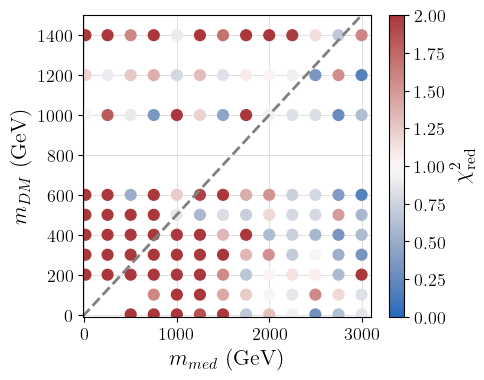

In [18]:
mmed = []
mdm = []
redChi = []

for f, rchi in redChis_dict.items():
    dm = int(f.split('_')[1])
    med = int(f.split('_')[2])

    mmed.append(med)
    mdm.append(dm)
    redChi.append(rchi)


plt.scatter(x=mmed, y=mdm, c=redChi, vmin=0., vmax=2.,
            cmap=plt.colormaps.get_cmap('vlag'), s=60)

plt.axline((1, 1), slope=1/2, linestyle='--', color='gray')

cbar=plt.colorbar(label=r'$\chi^{2}_{\rm red}$')
plt.xlabel(r'$m_{med}$ (GeV)')
plt.xlim(-20,3100)
plt.ylabel(r'$m_{DM}$ (GeV)')
plt.ylim(-10,1500)

plt.tight_layout()
# plt.savefig('./figures/comp-effs-spin1.png')

plt.show()

In [19]:
mtuple = []
for i, m in enumerate(mmed):
    mtuple.append((mdm[i], m))

In [20]:
mtuple.sort()

In [21]:
for pair in mtuple:
    print(pair, end=', ')

(1, 100), (1, 250), (1, 500), (1, 750), (1, 1000), (1, 1250), (1, 1500), (1, 1750), (1, 2000), (1, 2250), (1, 2500), (1, 2750), (1, 3000), (100, 10), (100, 250), (100, 300), (100, 500), (100, 750), (100, 1000), (100, 1250), (100, 1500), (100, 1750), (100, 2000), (100, 2250), (100, 2500), (100, 2750), (100, 3000), (200, 10), (200, 250), (200, 500), (200, 750), (200, 1000), (200, 1250), (200, 1500), (200, 1750), (200, 2000), (200, 2250), (200, 2500), (200, 2750), (200, 3000), (300, 10), (300, 250), (300, 500), (300, 750), (300, 1000), (300, 1250), (300, 1500), (300, 1750), (300, 1995), (300, 2250), (300, 2500), (300, 2750), (300, 3000), (400, 10), (400, 250), (400, 500), (400, 750), (400, 1000), (400, 1250), (400, 1500), (400, 1750), (400, 2000), (400, 2250), (400, 2500), (400, 2750), (400, 3000), (500, 10), (500, 250), (500, 500), (500, 750), (500, 995), (500, 1250), (500, 1500), (500, 1750), (500, 2000), (500, 2250), (500, 2500), (500, 2750), (500, 3000), (600, 10), (600, 250), (600, 5

In [22]:
len(mtuple)

131

In [23]:
# merge dfs
dataComb = pd.merge(dataAx, dataVec, on=['mchi (GeV)', 'mMed (GeV)', 'Signal Region'], how='inner')

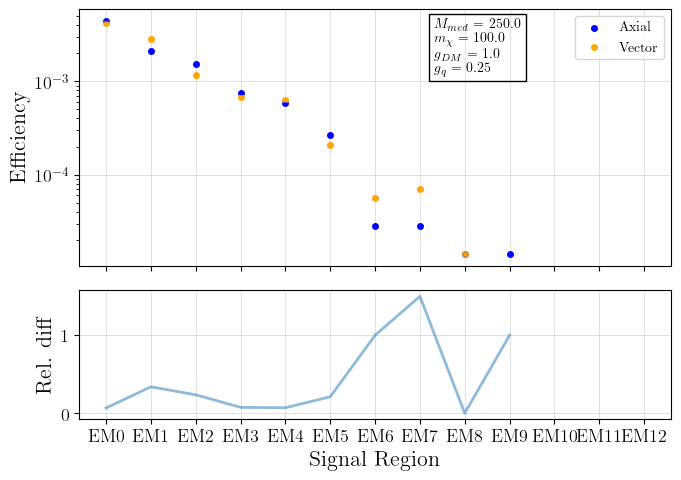

In [27]:
# plot eff diff
mxd = 100.
mmed = 250.
mFilter = (dataComb['mchi (GeV)'] == mxd) & (dataComb['mMed (GeV)'] == mmed)
x = dataComb[mFilter]['Signal Region']
y1 = dataComb[mFilter]['eff_a']
y1_err = dataComb[mFilter]['stat_a']
y2 = dataComb[mFilter]['eff_v']
y2_err = dataComb[mFilter]['stat_v']

params = {'$M_{med}$' : mmed, '$m_{\chi}$': mxd, '$g_{DM}$': 1., '$g_{q}$': 0.25}
textstr = '\n'.join([r'%s = %s' %(k,v) for k,v in params.items()])

fig, ax = plt.subplots(2, sharex=True, gridspec_kw={'height_ratios':[2,1]}, figsize=(7,5))

ax[0].scatter(x, y1, label='Axial', color='blue')
ax[0].errorbar(x, y1, yerr=y1_err, marker='.', linewidth=0.0, color='blue')
ax[0].scatter(x, y2, label='Vector', color='orange')
ax[0].errorbar(x, y2, yerr=y2_err, marker='.', linewidth=0.0, color='orange')

ax[0].set_yscale('log')

diff = np.abs(y1 - y2)
relDiff = diff/y1
diffError = diff/np.sqrt(y1_err**2 + y2_err**2)

ax[1].plot(x, relDiff, alpha=.5, label='rel diff')
# ax[1].plot(x, diffError, alpha=.5, label=r'$\Delta \epsilon / \sigma_{\epsilon}$')

ax[0].text(.6, 2.7, textstr, bbox=dict(facecolor='none', edgecolor='black'), transform=plt.gca().transAxes, fontsize=10)


ax[1].set_xlabel('Signal Region')
ax[0].set_ylabel('Efficiency')
ax[0].legend()
ax[1].set_ylabel('Rel. diff')
plt.tight_layout()

# plt.savefig('./figures/comp_eff_spin1.png')

plt.show()

In [28]:
y1

936    0.004454
937    0.002101
938    0.001541
939    0.000742
940    0.000588
941    0.000266
942    0.000028
943    0.000028
944    0.000014
945    0.000014
946    0.000000
947    0.000000
948    0.000000
Name: eff_a, dtype: float64

In [29]:
y1_err

936    1.112232e-06
937    3.603228e-07
938    2.262788e-07
939    7.567781e-08
940    5.338617e-08
941    1.624371e-08
942    5.547531e-10
943    5.547531e-10
944    1.961349e-10
945    1.961349e-10
946    0.000000e+00
947    0.000000e+00
948    0.000000e+00
Name: stat_a, dtype: float64

In [100]:
dataVec_new = pd.read_pickle('../ma5_test_vector_match/ma5Results_test_vector_match.pcl')
dataAx_new = pd.read_pickle('../ma5_test_axial_match/ma5Results_test_axial_match.pcl')

In [101]:
# choose only EM
srs = [c for c in dataAx_new['Signal Region'] if not 'IM' in c]
dataAx_new = dataAx_new[dataAx_new['Signal Region'].isin(srs)]
dataVec_new = dataVec_new[dataVec_new['Signal Region'].isin(srs)]

In [102]:
dataAx_new

,Signal Region,Sigma_95_exp (pb),Sigma_95_obs (pb),Sigma_theoretical (pb),SAF File,mMed (GeV),mchi (GeV),Efficiency,Efficiency_Err
13,EM0,92.583641,92.606957,276.0927,dma_100_250,250.0,100.0,0.004637,1.075050e-04
14,EM1,46.987566,46.976765,276.0927,dma_100_250,250.0,100.0,0.002614,8.376366e-05
15,EM2,32.750442,32.743613,276.0927,dma_100_250,250.0,100.0,0.001511,7.091360e-05
16,EM3,39.267812,39.577214,276.0927,dma_100_250,250.0,100.0,0.000752,2.242561e-05
17,EM4,38.267204,38.869657,276.0927,dma_100_250,250.0,100.0,0.000685,3.217050e-05
18,EM5,33.391418,34.229562,276.0927,dma_100_250,250.0,100.0,0.000231,8.148441e-06
19,EM6,45.831637,48.560246,276.0927,dma_100_250,250.0,100.0,0.000088,7.951834e-06
20,EM7,62.045541,69.260956,276.0927,dma_100_250,250.0,100.0,0.000032,2.153017e-06
21,EM8,57.350123,61.106272,276.0927,dma_100_250,250.0,100.0,0.000016,1.291206e-06
22,EM9,60.781024,54.772489,276.0927,dma_100_250,250.0,100.0,0.000007,9.786407e-07


In [103]:
dataVec_new

,Signal Region,Sigma_95_exp (pb),Sigma_95_obs (pb),Sigma_theoretical (pb),SAF File,mMed (GeV),mchi (GeV),Efficiency,Efficiency_Err
13,EM0,91.969957,91.993122,640.3959,dmv_100_250,250.0,100.0,0.004669,1.066803e-04
14,EM1,45.125985,45.114188,640.3959,dmv_100_250,250.0,100.0,0.002720,8.103377e-05
15,EM2,38.095991,38.088048,640.3959,dmv_100_250,250.0,100.0,0.001296,4.385584e-05
16,EM3,38.417130,38.719829,640.3959,dmv_100_250,250.0,100.0,0.000769,3.516686e-05
17,EM4,38.689571,39.298673,640.3959,dmv_100_250,250.0,100.0,0.000677,3.252566e-05
18,EM5,37.073061,38.003616,640.3959,dmv_100_250,250.0,100.0,0.000208,7.665222e-06
19,EM6,41.243114,43.698531,640.3959,dmv_100_250,250.0,100.0,0.000098,1.100990e-05
20,EM7,33.094652,36.943303,640.3959,dmv_100_250,250.0,100.0,0.000059,2.126702e-05
21,EM8,47.141221,50.228738,640.3959,dmv_100_250,250.0,100.0,0.000019,3.679570e-06
22,EM9,63.947607,57.626047,640.3959,dmv_100_250,250.0,100.0,0.000007,7.500524e-07


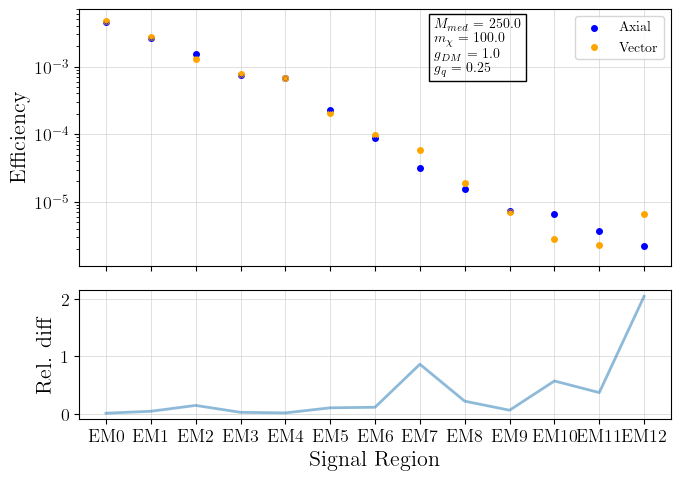

In [104]:
mmed = dataAx_new['mMed (GeV)'].tolist()[0]
mxd = dataAx_new['mchi (GeV)'].tolist()[0]

params = {'$M_{med}$' : mmed, '$m_{\chi}$': mxd, '$g_{DM}$': 1., '$g_{q}$': 0.25}
textstr = '\n'.join([r'%s = %s' %(k,v) for k,v in params.items()])

fig, ax = plt.subplots(2, sharex=True, gridspec_kw={'height_ratios':[2,1]}, figsize=(7,5))

x = dataAx_new['Signal Region']
y1 = np.array(dataAx_new['Efficiency'])
y2 = np.array(dataVec_new['Efficiency'])
y1_err = np.array(dataAx_new['Efficiency_Err'])
y2_err = np.array(dataVec_new['Efficiency_Err'])

ax[0].scatter(x, y1, label='Axial', color='blue')
ax[0].errorbar(x, y1, yerr=y1_err, marker='.', linewidth=0.0, color='blue')
ax[0].scatter(x, y2, label='Vector', color='orange')
ax[0].errorbar(x, y2, yerr=y2_err, marker='.', linewidth=0.0, color='orange')

ax[0].set_yscale('log')

diff = np.abs(y1 - y2)
relDiff = diff/y1
diffError = diff/np.sqrt(y1_err**2 + y2_err**2)

ax[1].plot(x, relDiff, alpha=.5, label='rel diff')
# ax[1].plot(x, diffError, alpha=.5, label=r'$\Delta \epsilon / \sigma_{\epsilon}$')

ax[0].text(.6, 2.7, textstr, bbox=dict(facecolor='none', edgecolor='black'), transform=plt.gca().transAxes, fontsize=10)


ax[1].set_xlabel('Signal Region')
ax[0].set_ylabel('Efficiency')
ax[0].legend()
ax[1].set_ylabel('Rel. diff')
plt.tight_layout()

# plt.savefig('./figures/comp_eff_spin1.png')

plt.show()

In [107]:
(y1 - y2)**2

array([9.72086811e-10, 1.12237410e-08, 4.63971677e-08, 2.73951844e-10,
       7.03687103e-11, 5.42477806e-10, 9.47055833e-11, 7.44422703e-10,
       1.12681386e-11, 1.90167368e-13, 1.36867162e-11, 1.77646933e-12,
       2.01146142e-11])

In [106]:
(y1_err**2 + y2_err**2)

array([2.29380082e-08, 1.35828224e-08, 6.95207376e-09, 1.73961626e-09,
       2.09285995e-09, 1.25152728e-10, 1.84449538e-10, 4.56921746e-10,
       1.52064502e-11, 1.52031616e-12, 2.95945077e-12, 3.80287910e-12,
       1.83385355e-11])

In [109]:
np.array((y1 - y2)**2 / (y1_err**2 + y2_err**2)).sum()/(dof)

np.float64(1.7721399190168754)

In [84]:
dataScalar_new = pd.read_pickle('../ma5_test_spin0_scalar_match/ma5Results_test_scalar_match.pcl')
dataPseudo_new = pd.read_pickle('../ma5_test_spin0_pseudo_match/ma5Results_test_pseudo_match.pcl')

In [85]:
# choose only EM
srs = [c for c in dataScalar_new['Signal Region'] if not 'IM' in c]
dataScalar_new = dataScalar_new[dataScalar_new['Signal Region'].isin(srs)]
dataPseudo_new = dataPseudo_new[dataPseudo_new['Signal Region'].isin(srs)]

In [86]:
dataScalar_new

,Signal Region,Sigma_95_exp (pb),Sigma_95_obs (pb),Sigma_theoretical (pb),SAF File,mMed (GeV),mchi (GeV),Efficiency,Efficiency_Err
13,EM0,28.991585,28.998887,1.301264,dms_1_350,1,1.0,0.014791,5.031022e-04
14,EM1,12.852657,12.849702,1.301264,dms_1_350,1,1.0,0.009550,2.620176e-04
15,EM2,8.364061,8.362317,1.301264,dms_1_350,1,1.0,0.005901,2.334939e-04
16,EM3,9.662193,9.738324,1.301264,dms_1_350,1,1.0,0.003058,9.309664e-05
17,EM4,9.276808,9.422926,1.301264,dms_1_350,1,1.0,0.002820,1.033406e-04
18,EM5,9.162013,9.391982,1.301264,dms_1_350,1,1.0,0.000841,2.131130e-05
19,EM6,13.164819,13.948593,1.301264,dms_1_350,1,1.0,0.000306,9.839137e-06
20,EM7,15.101814,16.858038,1.301264,dms_1_350,1,1.0,0.000130,2.549294e-05
21,EM8,18.273888,19.470728,1.301264,dms_1_350,1,1.0,0.000049,2.893295e-06
22,EM9,24.233837,21.838192,1.301264,dms_1_350,1,1.0,0.000018,1.236870e-06


In [87]:
dataPseudo_new

,Signal Region,Sigma_95_exp (pb),Sigma_95_obs (pb),Sigma_theoretical (pb),SAF File,mMed (GeV),mchi (GeV),Efficiency,Efficiency_Err
13,EM0,30.290153,30.297781,4.465051,dmp_1_350,1,1.0,0.014164,4.223470e-04
14,EM1,13.164313,13.161287,4.465051,dmp_1_350,1,1.0,0.009326,2.373667e-04
15,EM2,8.825366,8.823525,4.465051,dmp_1_350,1,1.0,0.005593,2.586481e-04
16,EM3,10.071019,10.150371,4.465051,dmp_1_350,1,1.0,0.002935,9.717783e-05
17,EM4,10.280444,10.442292,4.465051,dmp_1_350,1,1.0,0.002545,6.485633e-05
18,EM5,10.295219,10.553635,4.465051,dmp_1_350,1,1.0,0.000749,2.112310e-05
19,EM6,14.369305,15.224789,4.465051,dmp_1_350,1,1.0,0.000280,8.961815e-06
20,EM7,20.028271,22.357404,4.465051,dmp_1_350,1,1.0,0.000098,3.594650e-06
21,EM8,24.511813,26.117216,4.465051,dmp_1_350,1,1.0,0.000036,1.811863e-06
22,EM9,26.434241,23.821073,4.465051,dmp_1_350,1,1.0,0.000017,1.910783e-06


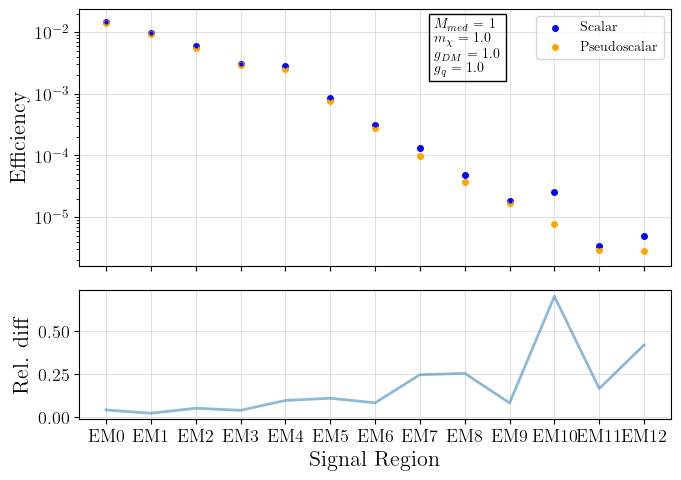

In [98]:
mmed = dataScalar_new['mMed (GeV)'].tolist()[0]
mxd = dataPseudo_new['mchi (GeV)'].tolist()[0]

params = {'$M_{med}$' : mmed, '$m_{\chi}$': mxd, '$g_{DM}$': 1., '$g_{q}$': 1.0}
textstr = '\n'.join([r'%s = %s' %(k,v) for k,v in params.items()])

fig, ax = plt.subplots(2, sharex=True, gridspec_kw={'height_ratios':[2,1]}, figsize=(7,5))

x = dataScalar_new['Signal Region']
y1 = np.array(dataScalar_new['Efficiency'])
y2 = np.array(dataPseudo_new['Efficiency'])
y1_err = np.array(dataScalar_new['Efficiency_Err'])
y2_err = np.array(dataPseudo_new['Efficiency_Err'])

ax[0].scatter(x, y1, label='Scalar', color='blue')
ax[0].errorbar(x, y1, yerr=y1_err, marker='.', linewidth=0.0, color='blue')
ax[0].scatter(x, y2, label='Pseudoscalar', color='orange')
ax[0].errorbar(x, y2, yerr=y2_err, linewidth=0.0, color='orange')

ax[0].set_yscale('log')

diff = np.abs(y1 - y2)
relDiff = diff/y1
diffError = diff/np.sqrt(y1_err**2 + y2_err**2)

ax[1].plot(x, relDiff, alpha=.5, label='rel diff')
# ax[1].plot(x, diffError, alpha=.5, label=r'$\Delta \epsilon / \sigma_{\epsilon}$')

ax[0].text(.6, 2.7, textstr, bbox=dict(facecolor='none', edgecolor='black'), transform=plt.gca().transAxes, fontsize=10)


ax[1].set_xlabel('Signal Region')
ax[0].set_ylabel('Efficiency')
ax[0].legend()
ax[1].set_ylabel('Rel. diff')
plt.tight_layout()

# plt.savefig('./figures/comp_eff_spin1.png')

plt.show()

In [89]:
np.abs(y1 - y2)/y1

array([0.0423474 , 0.02345732, 0.05221255, 0.04027256, 0.09758176,
       0.11047332, 0.08365225, 0.24697157, 0.25529742, 0.0829276 ,
       0.70238931, 0.16662399, 0.42014838])

In [90]:
(y1_err**2 + y2_err**2)

array([4.31488789e-07, 1.24996158e-07, 1.21418283e-07, 1.81105135e-08,
       1.48856271e-08, 9.00356913e-10, 1.77122743e-10, 6.62811423e-10,
       1.16540068e-11, 5.18094095e-12, 2.21119526e-10, 2.98627304e-13,
       6.11700043e-13])

In [99]:
np.array((y1 - y2)**2 / (y1_err**2 + y2_err**2)).sum()/(dof+1)

np.float64(3.555391307927692)

In [95]:
y1

array([1.47905786e-02, 9.54995230e-03, 5.90079526e-03, 3.05836714e-03,
       2.81997949e-03, 8.41477461e-04, 3.05992977e-04, 1.29749334e-04,
       4.88370093e-05, 1.84089989e-05, 2.55283201e-05, 3.45012366e-06,
       4.92763704e-06])

In [96]:
y1_err

array([5.03102207e-04, 2.62017597e-04, 2.33493949e-04, 9.30966353e-05,
       1.03340620e-04, 2.13113021e-05, 9.83913727e-06, 2.54929385e-05,
       2.89329529e-06, 1.23687033e-06, 1.48545702e-05, 3.75098867e-07,
       7.40438194e-07])

In [77]:
3.096063e+03/2.093267e+05

0.014790578554957395

In [81]:
(np.sqrt(1.109077e+04) / 2.093267e+05) * 0.014790578554957395

np.float64(7.441172715443876e-06)

In [82]:
(3.096063e+03/2.093267e+05) * (np.sqrt(1.109077e+04))/ 3.096063e+03

np.float64(0.0005031022071107421)

In [83]:
np.sqrt(1.109077e+04) / 2.093267e+05

np.float64(0.0005031022071107421)

In [110]:
2.789887908142857*1e3*139

387794.4192318572

In [111]:
1.301264e+00*1e3*139

180875.696